# Car Price Prediction with Machine Learning
**CodeAlpha Data Science Internship - Task 3**

Goal: predict a car's selling price from features such as age, mileage, fuel type and more.

Place `car data.csv` in the same folder as this notebook.

In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
file = (glob.glob("*car*.csv") + glob.glob("**/*car*.csv", recursive=True))[0]
df = pd.read_csv(file)
print("Loaded:", file)
df.head()

Loaded: car data.csv


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 1. Data overview and cleaning

In [3]:
print(df.shape)
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
df.describe()

(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64
Duplicate rows: 2


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [4]:
# Column lookup that tolerates different naming
def col(name):
    return [c for c in df.columns if c.lower().replace(" ", "_") == name.lower()][0]

target = col("Selling_Price")
year_col = col("Year")
print("Target:", target)
for c in df.select_dtypes("object").columns:
    print(f"\n{c}: {df[c].nunique()} unique values")
    if df[c].nunique() < 10:
        print(df[c].value_counts())

Target: Selling_Price

Car_Name: 98 unique values

Fuel_Type: 3 unique values
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Selling_type: 2 unique values
Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission: 2 unique values
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


## 2. Feature engineering

In [5]:
current_year = datetime.now().year
df["Car_Age"] = current_year - df[year_col]
df = df.drop(columns=[year_col])

# Car name has too many unique values to encode directly -> keep brand only
name_cols = [c for c in df.columns if c.lower().replace(" ", "_") == "car_name"]
if name_cols:
    df["Brand"] = df[name_cols[0]].str.split().str[0].str.lower()
    df = df.drop(columns=name_cols)
    print("Brands:", df["Brand"].nunique())

df.head()

Brands: 44


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,wagon
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,swift


## 3. Exploratory analysis

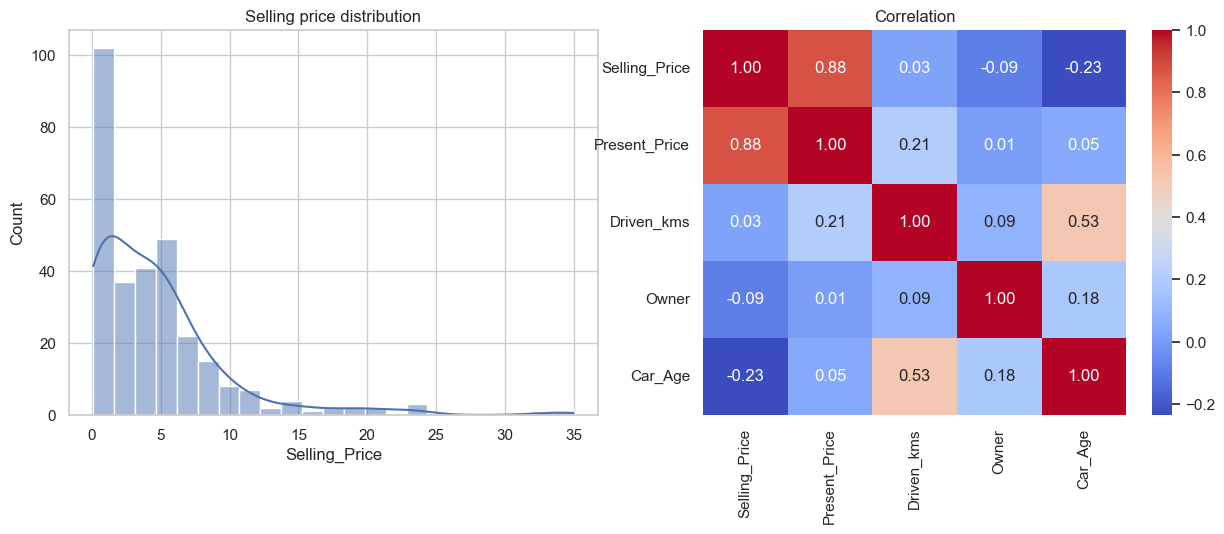

In [6]:
num = df.select_dtypes("number")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df[target], kde=True, ax=axes[0]).set_title("Selling price distribution")
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1]).set_title("Correlation")
plt.show()

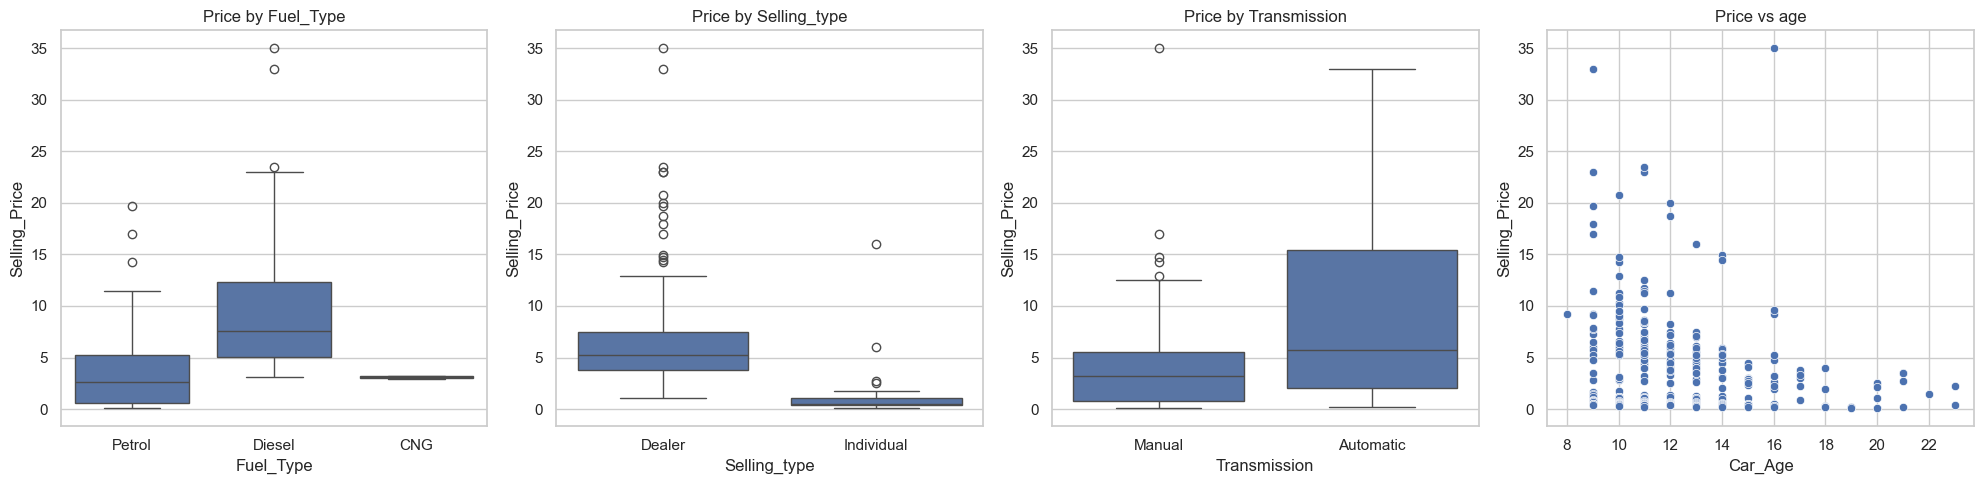

In [7]:
cats = df.select_dtypes("object").columns.drop("Brand", errors="ignore")
fig, axes = plt.subplots(1, len(cats) + 1, figsize=(5 * (len(cats) + 1), 5))
for ax, c in zip(axes, cats):
    sns.boxplot(data=df, x=c, y=target, ax=ax).set_title(f"Price by {c}")
sns.scatterplot(data=df, x="Car_Age", y=target, ax=axes[-1]).set_title("Price vs age")
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [8]:
df_model = pd.get_dummies(df, drop_first=True)
X = df_model.drop(columns=[target])
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Features:", X.shape[1], "| Train:", X_train.shape, "| Test:", X_test.shape)

Features: 51 | Train: (239, 51) | Test: (60, 51)


## 5. Compare models

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}
rows = []
for name, m in models.items():
    cv = cross_val_score(m, X_train, y_train, cv=5, scoring="r2").mean()
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    rows.append([name, cv, r2_score(y_test, p), mean_absolute_error(y_test, p), np.sqrt(mean_squared_error(y_test, p))])
results = pd.DataFrame(rows, columns=["Model", "CV R2", "Test R2", "MAE", "RMSE"]).set_index("Model")
results.round(3)

,CV R2,Test R2,MAE,RMSE
Model,,,,
Linear Regression,0.738,0.553,1.808,3.396
Ridge,0.845,0.777,1.351,2.396
Random Forest,0.886,0.555,1.393,3.385
Gradient Boosting,0.877,0.727,1.161,2.653


## 6. Tune the best tree model

In [10]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_dist, n_iter=15, cv=5, scoring="r2", random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best = search.best_estimator_
print("Best params:", search.best_params_)

Best params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}


## 7. Final evaluation

R2   : 0.6022
MAE  : 1.3487
RMSE : 3.2018


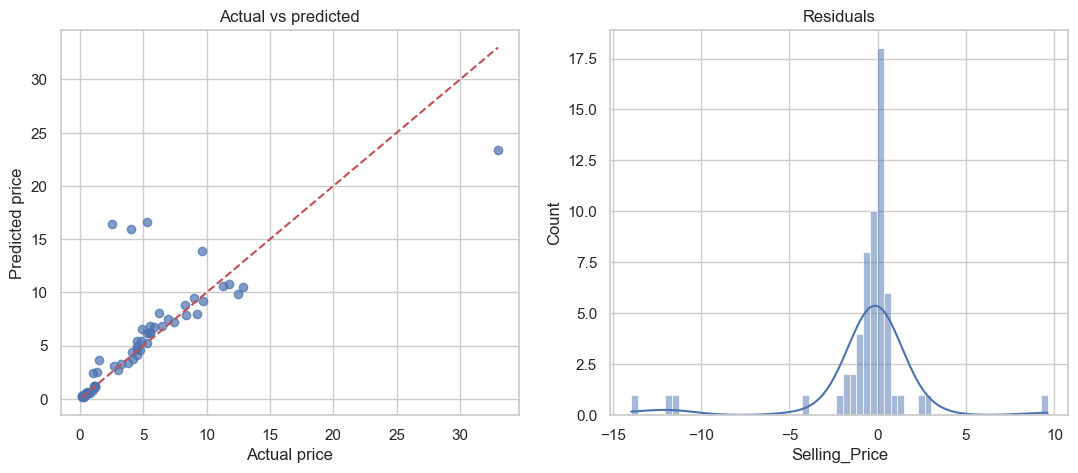

In [11]:
pred = best.predict(X_test)
print(f"R2   : {r2_score(y_test, pred):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, pred)):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, pred, alpha=0.7)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[0].plot(lims, lims, "r--")
axes[0].set(xlabel="Actual price", ylabel="Predicted price", title="Actual vs predicted")
sns.histplot(y_test - pred, kde=True, ax=axes[1]).set_title("Residuals")
plt.show()

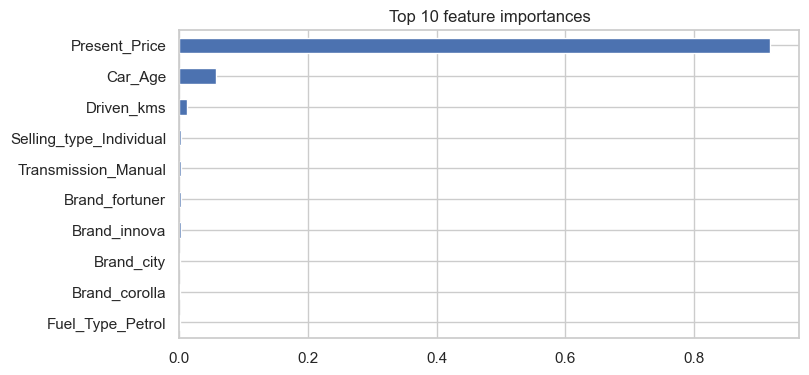

In [12]:
imp = pd.Series(best.feature_importances_, index=X.columns).sort_values().tail(10)
imp.plot(kind="barh", figsize=(8, 4), title="Top 10 feature importances")
plt.show()

## Conclusions
- **Present price** (current showroom price) is by far the strongest predictor of selling price, followed by **car age**.
- Older cars and cars with higher kilometres driven sell for less; automatic transmission and diesel/petrol differences also shift the price.
- Tree-based models (Random Forest / Gradient Boosting) outperform linear models because the price relationships are non-linear.
- Possible improvements: more data, log-transforming the price, and gradient boosting libraries such as XGBoost/LightGBM.